# Model Selection and Training
Compares Logistic Regression, Random Forest, XGBoost — selects best model for production.

In [1]:
import os
import sys

os.chdir(r"C:\Users\faffo\Project\INSURANCE_RISK_ML_MODEL")
sys.path.insert(0, os.getcwd())

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report
from src.data.loader import load_config, load_raw_data, split_features_target
from src.features.engineer import build_preprocessor

config = load_config("configs/config.yaml")
df = load_raw_data("data/raw/medical_insurance.csv")
X, y = split_features_target(df, config)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 1069 | Test: 268


## 1. Baseline Model Comparison (5-Fold CV AUC)

In [2]:
preprocessor = build_preprocessor(config)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8,
                              scale_pos_weight=0.6, eval_metric="auc", random_state=42),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}
for name, clf in models.items():
    pipe = Pipeline([("pre", build_preprocessor(config)), ("clf", clf)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")
    results[name] = scores
    print(f"{name:25s}  AUC: {scores.mean():.4f} +/- {scores.std():.4f}")

Logistic Regression        AUC: 0.8912 +/- 0.0427
Random Forest              AUC: 0.8738 +/- 0.0314
XGBoost                    AUC: 0.8775 +/- 0.0417


## 2. CV AUC Boxplot

C:\Users\faffo\AppData\Local\Temp\ipykernel_22780\2043891164.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([results[m] for m in results], labels=list(results.keys()), patch_artist=True,


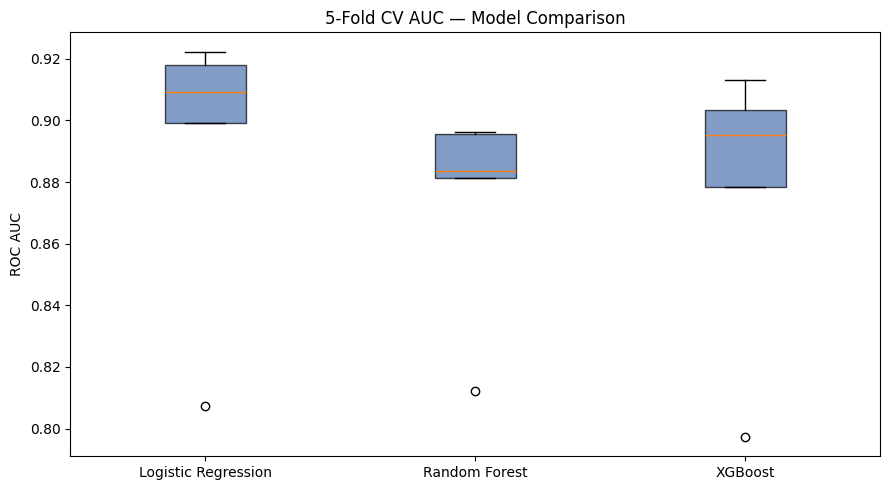

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot([results[m] for m in results], labels=list(results.keys()), patch_artist=True,
           boxprops=dict(facecolor="#4C72B0", alpha=0.7))
ax.set_title("5-Fold CV AUC — Model Comparison")
ax.set_ylabel("ROC AUC")
plt.tight_layout()
plt.savefig("artifacts/plots/model_comparison_cv_auc.png", bbox_inches="tight")
plt.show()

## 3. XGBoost Hyperparameter Tuning

In [4]:
param_dist = {
    "clf__n_estimators": [100, 200, 300],
    "clf__max_depth": [4, 6, 8],
    "clf__learning_rate": [0.01, 0.05, 0.1],
    "clf__subsample": [0.7, 0.8, 0.9],
    "clf__colsample_bytree": [0.7, 0.8, 0.9],
}
pipe_xgb = Pipeline([("pre", build_preprocessor(config)),
                     ("clf", XGBClassifier(eval_metric="auc", random_state=42))])
search = RandomizedSearchCV(pipe_xgb, param_dist, n_iter=20, cv=3,
                             scoring="roc_auc", random_state=42, verbose=1, n_jobs=-1)
search.fit(X_train, y_train)
print("Best AUC:", round(search.best_score_, 4))
print("Best Params:", search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best AUC: 0.8839
Best Params: {'clf__subsample': 0.9, 'clf__n_estimators': 300, 'clf__max_depth': 4, 'clf__learning_rate': 0.01, 'clf__colsample_bytree': 0.9}


## 4. Final Test Set Evaluation

In [5]:
best_pipe = search.best_estimator_
y_prob = best_pipe.predict_proba(X_test)[:, 1]
y_pred = best_pipe.predict(X_test)
print(f"Test AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(classification_report(y_test, y_pred, target_names=["Low Risk","High Risk"]))

Test AUC: 0.8926
              precision    recall  f1-score   support

    Low Risk       0.92      1.00      0.96       201
   High Risk       0.98      0.75      0.85        67

    accuracy                           0.93       268
   macro avg       0.95      0.87      0.90       268
weighted avg       0.94      0.93      0.93       268



## 5. Learning Curves

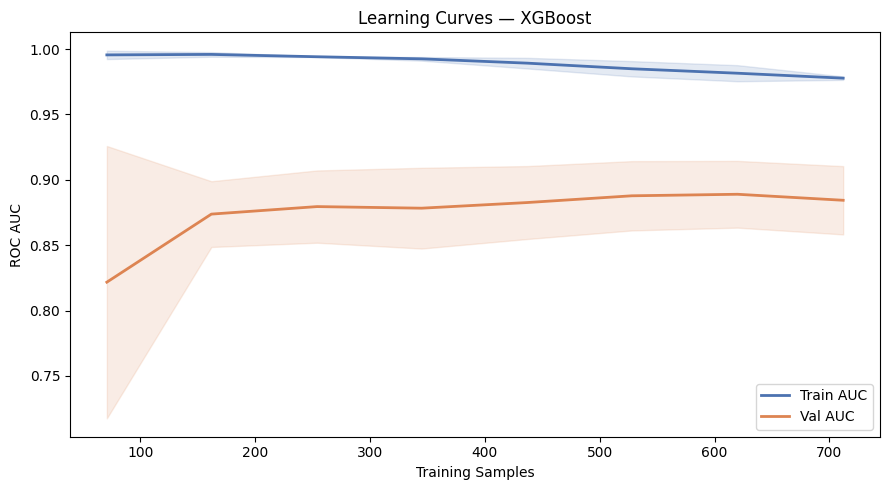

In [6]:
from sklearn.model_selection import learning_curve
train_sizes, train_scores, val_scores = learning_curve(
    search.best_estimator_, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8), cv=3, scoring="roc_auc", n_jobs=-1
)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), label="Train AUC", color="#4C72B0", lw=2)
ax.fill_between(train_sizes, train_scores.mean(1)-train_scores.std(1),
                train_scores.mean(1)+train_scores.std(1), alpha=0.15, color="#4C72B0")
ax.plot(train_sizes, val_scores.mean(axis=1), label="Val AUC", color="#DD8452", lw=2)
ax.fill_between(train_sizes, val_scores.mean(1)-val_scores.std(1),
                val_scores.mean(1)+val_scores.std(1), alpha=0.15, color="#DD8452")
ax.set_xlabel("Training Samples")
ax.set_ylabel("ROC AUC")
ax.set_title("Learning Curves — XGBoost")
ax.legend()
plt.tight_layout()
plt.savefig("artifacts/plots/model_learning_curves.png", bbox_inches="tight")
plt.show()